# RETINEXPLAIN - Statistical Comparison: Soft F1 vs Soft MCC vs Weighted RMSE
**Student:** Ashik Kannampilly Janardhanan | MSc AI & ML | University of Limerick
**Purpose:** Statistical validity analysis comparing the 30-run validation Macro F1 distributions of all three fitness functions (Soft F1, Soft MCC, Weighted RMSE).

## Cell 1 -- Libraries

#### Importing all the required libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import itertools
import os

OUTPUT_PATH = '/kaggle/working/'
print("Libraries loaded.")

Libraries loaded.


## Cell 2 -- Load 30-Run Val Macro F1 Arrays

#### Loading the saved .npy files from all three main notebooks (Soft F1, Soft MCC, Weighted RMSE).

In [2]:
softf1_scores  = np.load('/kaggle/input/datasets/ashik02/retinexplain-stats/val_f1_per_run_softf1.npy')
softmcc_scores = np.load('/kaggle/input/datasets/ashik02/retinexplain-stats/val_f1_per_run_softmcc.npy')
rmse_scores    = np.load('/kaggle/input/datasets/ashik02/retinexplain-stats/val_f1_per_run_weighted_rmse.npy')

labels = ['Soft F1', 'Soft MCC', 'Weighted RMSE']
all_scores = [softf1_scores, softmcc_scores, rmse_scores]

for name, arr in zip(labels, all_scores):
    print(f"{name:<15} — {len(arr)} runs loaded")
print()
for name, arr in zip(labels, all_scores):
    print(f"{name} scores:", np.round(arr, 4))

Soft F1         — 30 runs loaded
Soft MCC        — 30 runs loaded
Weighted RMSE   — 30 runs loaded

Soft F1 scores: [0.3644 0.286  0.3075 0.3758 0.374  0.3709 0.354  0.3611 0.4059 0.3597
 0.388  0.2503 0.398  0.3767 0.261  0.334  0.3164 0.2939 0.3325 0.3752
 0.4099 0.2844 0.3445 0.3178 0.3891 0.2977 0.3548 0.3344 0.3259 0.3007]
Soft MCC scores: [0.326  0.3381 0.3416 0.2753 0.2514 0.2474 0.2939 0.3063 0.3449 0.3289
 0.3247 0.2915 0.2474 0.2762 0.2648 0.3158 0.2411 0.2596 0.2472 0.3513
 0.3215 0.3574 0.3206 0.3876 0.3249 0.2778 0.2754 0.3419 0.286  0.1993]
Weighted RMSE scores: [0.2647 0.3373 0.3936 0.173  0.358  0.3073 0.3515 0.2976 0.3321 0.2573
 0.2222 0.2667 0.3269 0.2624 0.2709 0.341  0.2047 0.3333 0.3019 0.1708
 0.31   0.2553 0.3066 0.3604 0.2258 0.2816 0.4158 0.284  0.1672 0.3293]


## Cell 3 -- Descriptive Statistics

#### Summary statistics of the 30-run validation Macro F1 distributions for all three fitness functions. Mean and standard deviation show the average performance and consistency across runs.

In [3]:
print("Descriptive Statistics — 30-Run Validation Macro F1")
print("=" * 76)
print(f"{'Metric':<20}  {'Soft F1':>12}  {'Soft MCC':>12}  {'Weighted RMSE':>15}")
print("-" * 76)
metrics = [('Mean', np.mean), ('Std', np.std), ('Min', np.min), ('Max', np.max), ('Median', np.median)]
for mname, mfunc in metrics:
    vals = [mfunc(arr) for arr in all_scores]
    print(f"{mname:<20}  {vals[0]:>12.4f}  {vals[1]:>12.4f}  {vals[2]:>15.4f}")

Descriptive Statistics — 30-Run Validation Macro F1
Metric                     Soft F1      Soft MCC    Weighted RMSE
----------------------------------------------------------------------------
Mean                        0.3415        0.2989           0.2903
Std                         0.0421        0.0425           0.0622
Min                         0.2503        0.1993           0.1672
Max                         0.4099        0.3876           0.4158
Median                      0.3493        0.3001           0.2998


## Cell 4 -- Shapiro-Wilk Normality Test

#### Tests whether the 30-run validation Macro F1 distribution of each fitness function is normally distributed.

In [4]:
print("Shapiro-Wilk Normality Test")
print("=" * 60)

normality = {}
for name, arr in zip(labels, all_scores):
    stat, p = stats.shapiro(arr)
    normality[name] = p > 0.05
    print(f"{name:<15} — W: {stat:.4f}  p: {p:.4f}  {'NORMAL' if p > 0.05 else 'NOT NORMAL'}")
print()

all_normal = all(normality.values())
print("All three distributions normal." if all_normal else "At least one distribution is not normal — Wilcoxon will be used where needed below.")

Shapiro-Wilk Normality Test
Soft F1         — W: 0.9675  p: 0.4726  NORMAL
Soft MCC        — W: 0.9738  p: 0.6476  NORMAL
Weighted RMSE   — W: 0.9709  p: 0.5652  NORMAL

All three distributions normal.


## Cell 5 -- Pairwise Comparisons

#### This checks whether each fitness function's 30-run validation scores are actually better than the other two, or if the difference could just be random chance. For each pair (Soft F1 vs Soft MCC, Soft F1 vs Weighted RMSE, Soft MCC vs Weighted RMSE), it first checks if the score differences follow a normal pattern, then runs the appropriate test (t-test or Wilcoxon) to see if one is genuinely better, not just numerically higher.

In [5]:
pairs = list(itertools.combinations(range(3), 2))
alpha = 0.05

print("Pairwise Comparisons")
print("=" * 76)

posthoc_results = []

for i, j in pairs:
    name_i, name_j = labels[i], labels[j]
    arr_i, arr_j = all_scores[i], all_scores[j]
    diffs = arr_i - arr_j

    diff_stat, diff_p = stats.shapiro(diffs)
    diffs_normal = diff_p > 0.05

    if diffs_normal:
        test_stat, test_p = stats.ttest_rel(arr_i, arr_j)
        test_name = 'Paired t-test'
    else:
        test_stat, test_p = stats.wilcoxon(arr_i, arr_j)
        test_name = 'Wilcoxon signed-rank'

    significant = test_p < alpha
    higher_mean = name_i if np.mean(arr_i) > np.mean(arr_j) else name_j

    print(f"{name_i} vs {name_j}")
    print(f"  Shapiro-Wilk on differences : W={diff_stat:.4f}, p={diff_p:.4f} ({'normal' if diffs_normal else 'not normal'})")
    print(f"  Test used  : {test_name}")
    print(f"  Statistic : {test_stat:.4f}")
    print(f"  p-value : {test_p:.4f}")
    if significant:
        print(f"  Result: SIGNIFICANT (p < {alpha}) — {higher_mean} is better.")
    else:
        print(f"  Result: NOT significant (p >= {alpha}). ({higher_mean} has a nominally higher mean, but the difference isn't statistically reliable.)")
    print()

    posthoc_results.append({
        'pair': f'{name_i} vs {name_j}', 'test': test_name, 'statistic': test_stat,
        'p_value': test_p, 'significant': significant,
        'higher_mean': higher_mean, 'winner': higher_mean if significant else None
    })

Pairwise Comparisons
Soft F1 vs Soft MCC
  Shapiro-Wilk on differences : W=0.9701, p=0.5415 (normal)
  Test used  : Paired t-test
  Statistic : 4.0298
  p-value : 0.0004
  Result: SIGNIFICANT (p < 0.05) — Soft F1 is better.

Soft F1 vs Weighted RMSE
  Shapiro-Wilk on differences : W=0.9695, p=0.5262 (normal)
  Test used  : Paired t-test
  Statistic : 3.5306
  p-value : 0.0014
  Result: SIGNIFICANT (p < 0.05) — Soft F1 is better.

Soft MCC vs Weighted RMSE
  Shapiro-Wilk on differences : W=0.9807, p=0.8433 (normal)
  Test used  : Paired t-test
  Statistic : 0.6034
  p-value : 0.5509
  Result: NOT significant (p >= 0.05). (Soft MCC has a nominally higher mean, but the difference isn't statistically reliable.)



## Cell 6 -- Distribution Plot

#### Visual comparison of the 30-run validation Macro F1 distributions for all three fitness functions. Histogram shows the spread and overlap between the distributions. Boxplot shows median, interquartile range and outliers. Per-run line plot shows how each fitness function performed across all 30 individual runs.

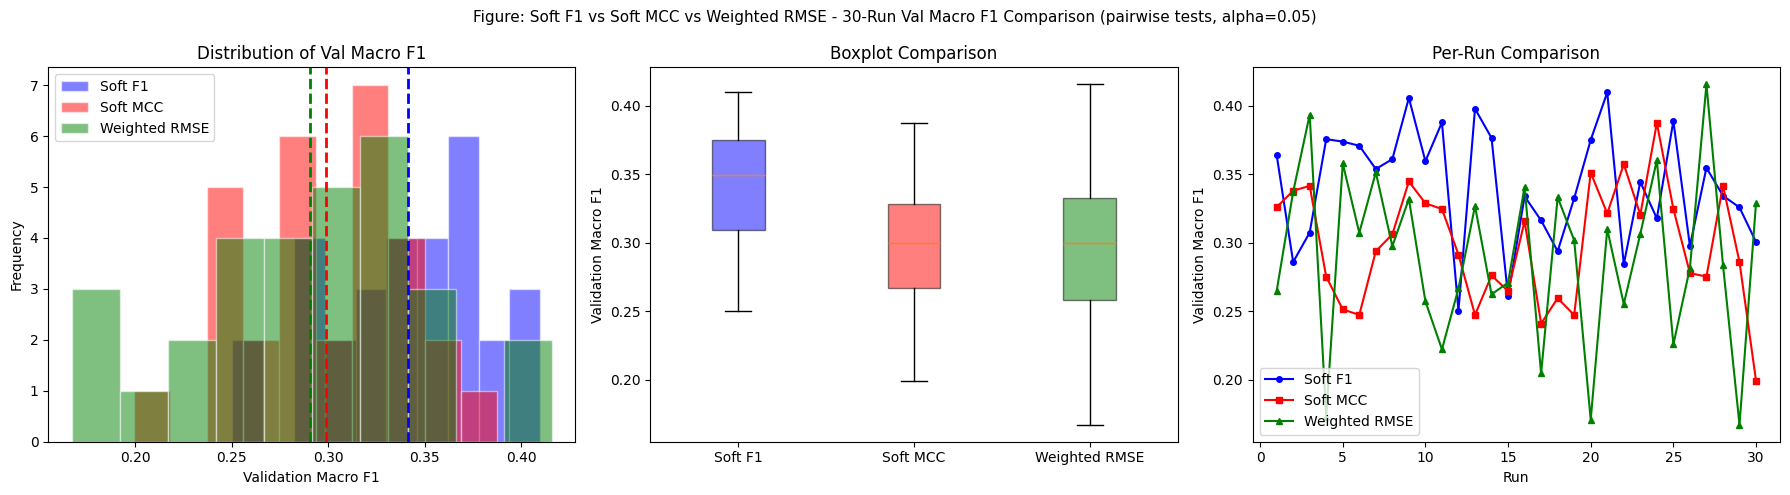

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['blue', 'red', 'green']

# Histogram
for arr, name, c in zip(all_scores, labels, colors):
    axes[0].hist(arr, bins=10, alpha=0.5, color=c, label=name, edgecolor='white')
    axes[0].axvline(np.mean(arr), color=c, linestyle='--', linewidth=2)
axes[0].set_xlabel('Validation Macro F1')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Val Macro F1')
axes[0].legend()

# Boxplot
bp = axes[1].boxplot(all_scores, tick_labels=labels, patch_artist=True)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.5)
axes[1].set_ylabel('Validation Macro F1')
axes[1].set_title('Boxplot Comparison')

# Per-run comparison
x = np.arange(1, 31)
markers = ['o', 's', '^']
for arr, name, c, m in zip(all_scores, labels, colors, markers):
    axes[2].plot(x, arr, f'{m}-', color=c, label=name, markersize=4)
axes[2].set_xlabel('Run')
axes[2].set_ylabel('Validation Macro F1')
axes[2].set_title('Per-Run Comparison')
axes[2].legend()

plt.suptitle('Figure: Soft F1 vs Soft MCC vs Weighted RMSE - 30-Run Val Macro F1 Comparison (pairwise tests, alpha=0.05)', fontsize=11)
plt.tight_layout()
plt.show()

## Cell 7 -- Summary

#### Final summary combining the statistical test results with the test set performance. Soft F1 is selected as the chosen fitness function based on significantly higher validation Macro F1 across 30 runs than both Soft MCC and Weighted RMSE, and the best test set Macro F1 with all 7 classes detected

In [7]:
print("=" * 76)
print("STATISTICAL COMPARISON SUMMARY — SOFT F1 vs SOFT MCC vs WEIGHTED RMSE")
print("=" * 76)
print()
for name, arr in zip(labels, all_scores):
    print(f"  {name:<15} — Mean Val Macro F1: {np.mean(arr):.4f} ± {np.std(arr):.4f}")
print()
print("  Pairwise results (alpha = 0.05):")
for r in posthoc_results:
    if r['significant']:
        verdict = f"{r['winner']} significantly better"
    else:
        verdict = f"no significant difference ({r['higher_mean']} nominally higher)"
    print(f"    {r['pair']:<30} ({r['test']}, p={r['p_value']:.4f}): {verdict}")
print()
best_name = labels[int(np.argmax([np.mean(a) for a in all_scores]))]
print(f"  Chosen model for dissertation: {best_name} (highest mean validation Macro F1, confirm against test-set Macro F1 and class coverage)")

STATISTICAL COMPARISON SUMMARY — SOFT F1 vs SOFT MCC vs WEIGHTED RMSE

  Soft F1         — Mean Val Macro F1: 0.3415 ± 0.0421
  Soft MCC        — Mean Val Macro F1: 0.2989 ± 0.0425
  Weighted RMSE   — Mean Val Macro F1: 0.2903 ± 0.0622

  Pairwise results (alpha = 0.05):
    Soft F1 vs Soft MCC            (Paired t-test, p=0.0004): Soft F1 significantly better
    Soft F1 vs Weighted RMSE       (Paired t-test, p=0.0014): Soft F1 significantly better
    Soft MCC vs Weighted RMSE      (Paired t-test, p=0.5509): no significant difference (Soft MCC nominally higher)

  Chosen model for dissertation: Soft F1 (highest mean validation Macro F1, confirm against test-set Macro F1 and class coverage)
